In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
sys.path.append('..')
from environments.line_world import LineWorldEnv

from algorithms.dynamic_programming import (
    iterative_policy_evaluation,
    policy_iteration,
    value_iteration
)

In [5]:
S = LineWorldEnv.S
A = LineWorldEnv.A
R = LineWorldEnv.R
T = LineWorldEnv.T
p = LineWorldEnv.p

print("MDP LineWorld défini ✅")
print(f"États : {S}")
print(f"Actions : {A} (0=Gauche, 1=Droite)")
print(f"Rewards : {R}")
print(f"États terminaux : {T}")

MDP LineWorld défini ✅
États : [0 1 2 3 4]
Actions : [0 1] (0=Gauche, 1=Droite)
Rewards : [ 0. -1.  1.]
États terminaux : [0 4]


In [6]:
pi_right = np.zeros((len(S), len(A)))
pi_right[:, 1] = 1.0

pi_left = np.zeros((len(S), len(A)))
pi_left[:, 0] = 1.0

pi_random = np.ones((len(S), len(A))) / len(A)

pi_mostly_right = np.zeros((len(S), len(A)))
pi_mostly_right[:, 0] = 0.2
pi_mostly_right[:, 1] = 0.8

V_right = iterative_policy_evaluation(S, A, R, p, T, pi_right)
V_left = iterative_policy_evaluation(S, A, R, p, T, pi_left)
V_random = iterative_policy_evaluation(S, A, R, p, T, pi_random)
V_mostly_right = iterative_policy_evaluation(S, A, R, p, T, pi_mostly_right)

print(f"V toujours Droite     : {V_right.round(3)}")
print(f"V toujours Gauche     : {V_left.round(3)}")
print(f"V aléatoire           : {V_random.round(3)}")
print(f"V mostly Droite (80%) : {V_mostly_right.round(3)}")

V toujours Droite     : [0. 1. 1. 1. 0.]
V toujours Gauche     : [ 0. -1. -1. -1.  0.]
V aléatoire           : [ 0.  -0.5  0.   0.5  0. ]
V mostly Droite (80%) : [0.    0.506 0.882 0.976 0.   ]


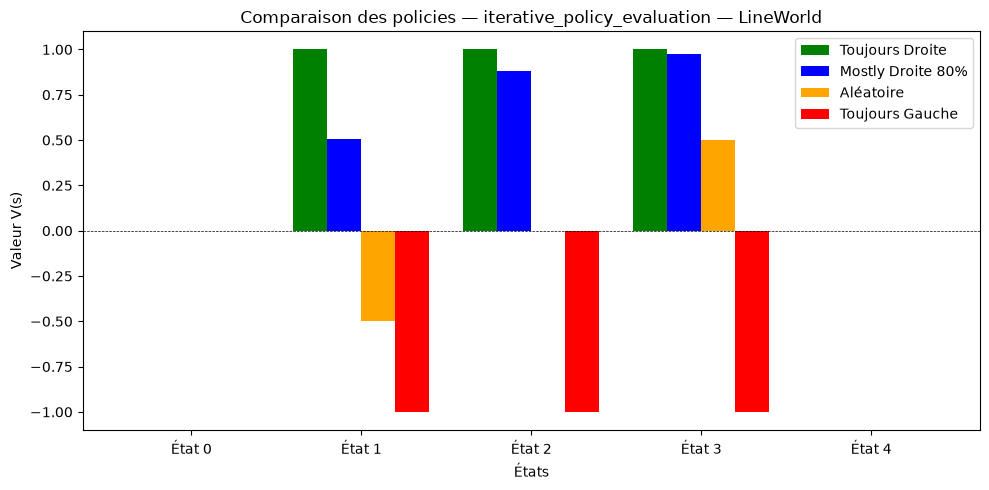

In [7]:
states = ['État 0', 'État 1', 'État 2', 'État 3', 'État 4']
x = np.arange(len(states))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*width, V_right,        width, label='Toujours Droite', color='green')
ax.bar(x - 0.5*width, V_mostly_right, width, label='Mostly Droite 80%', color='blue')
ax.bar(x + 0.5*width, V_random,       width, label='Aléatoire', color='orange')
ax.bar(x + 1.5*width, V_left,         width, label='Toujours Gauche', color='red')

ax.set_xlabel('États')
ax.set_ylabel('Valeur V(s)')
ax.set_title('Comparaison des policies — iterative_policy_evaluation — LineWorld')
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.legend()
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [8]:
t1 = time.time()
pi_pi, V_pi = policy_iteration(S, A, R, p, T)
t1 = time.time() - t1

t2 = time.time()
pi_vi, V_vi = value_iteration(S, A, R, p, T)
t2 = time.time() - t2

print("=== Policy Iteration vs Value Iteration ===")
print(f"Policy Iteration : V = {V_pi.round(3)} | temps = {t1:.4f}s")
print(f"Value Iteration  : V = {V_vi.round(3)} | temps = {t2:.4f}s")
print(f"\nPolicy PI : {['Droite' if a==1 else 'Gauche' for a in pi_pi.argmax(axis=1)]}")
print(f"Policy VI : {['Droite' if a==1 else 'Gauche' for a in pi_vi.argmax(axis=1)]}")

=== Policy Iteration vs Value Iteration ===
Policy Iteration : V = [0. 1. 1. 1. 0.] | temps = 0.0013s
Value Iteration  : V = [0. 1. 1. 1. 0.] | temps = 0.0011s

Policy PI : ['Droite', 'Droite', 'Droite', 'Droite', 'Droite']
Policy VI : ['Gauche', 'Droite', 'Droite', 'Droite', 'Gauche']


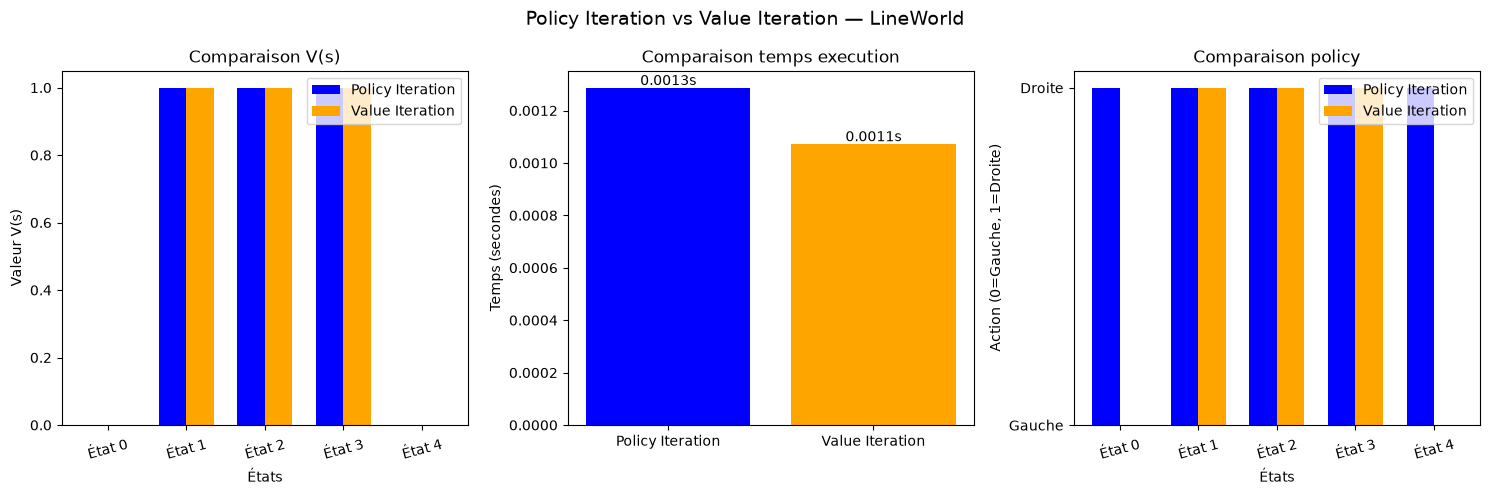

In [9]:
# Graphique comparaison PI vs VI
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Graphique 1 — Comparaison V
states = ['État 0', 'État 1', 'État 2', 'État 3', 'État 4']
x = np.arange(len(states))
width = 0.35

axes[0].bar(x - width/2, V_pi, width, label='Policy Iteration', color='blue')
axes[0].bar(x + width/2, V_vi, width, label='Value Iteration', color='orange')
axes[0].set_xlabel('États')
axes[0].set_ylabel('Valeur V(s)')
axes[0].set_title('Comparaison V(s)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(states, rotation=15)
axes[0].legend()
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Graphique 2 — Comparaison temps
algos = ['Policy Iteration', 'Value Iteration']
temps = [t1, t2]
colors = ['blue', 'orange']
axes[1].bar(algos, temps, color=colors)
axes[1].set_ylabel('Temps (secondes)')
axes[1].set_title('Comparaison temps execution')
for i, t in enumerate(temps):
    axes[1].text(i, t + 0.00001, f'{t:.4f}s', ha='center')

# Graphique 3 — Comparaison policy
pi_actions = np.argmax(pi_pi, axis=1)
vi_actions = np.argmax(pi_vi, axis=1)
x = np.arange(len(states))
axes[2].bar(x - width/2, pi_actions, width, label='Policy Iteration', color='blue')
axes[2].bar(x + width/2, vi_actions, width, label='Value Iteration', color='orange')
axes[2].set_xlabel('États')
axes[2].set_ylabel('Action (0=Gauche, 1=Droite)')
axes[2].set_title('Comparaison policy')
axes[2].set_xticks(x)
axes[2].set_xticklabels(states, rotation=15)
axes[2].legend()
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Gauche', 'Droite'])

plt.suptitle('Policy Iteration vs Value Iteration — LineWorld', fontsize=14)
plt.tight_layout()
plt.show()

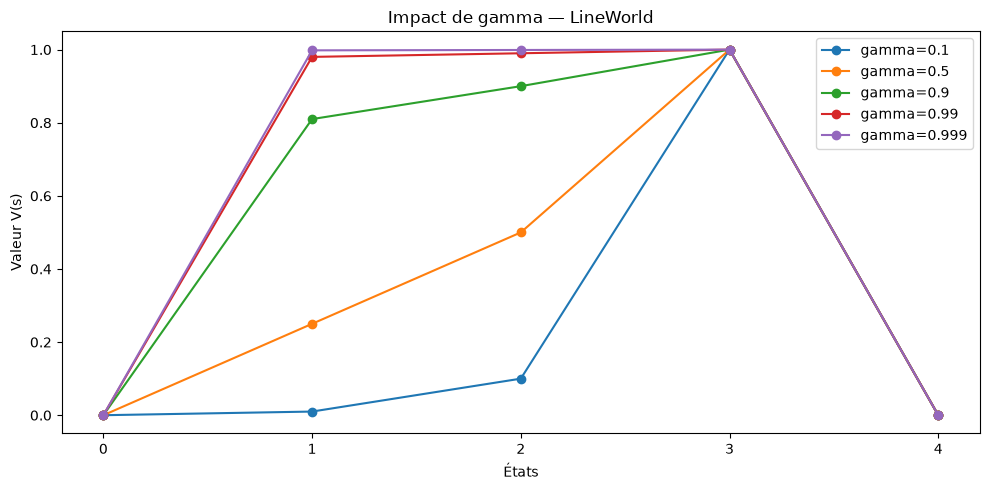

In [10]:
gammas = [0.1, 0.5, 0.9, 0.99, 0.999]

fig, ax = plt.subplots(figsize=(10, 5))
for g in gammas:
    _, V = value_iteration(S, A, R, p, T, gamma=g)
    ax.plot(S, V, marker='o', label=f'gamma={g}')

ax.set_xlabel('États')
ax.set_ylabel('Valeur V(s)')
ax.set_title('Impact de gamma — LineWorld')
ax.legend()
ax.set_xticks(S)
plt.tight_layout()
plt.show()

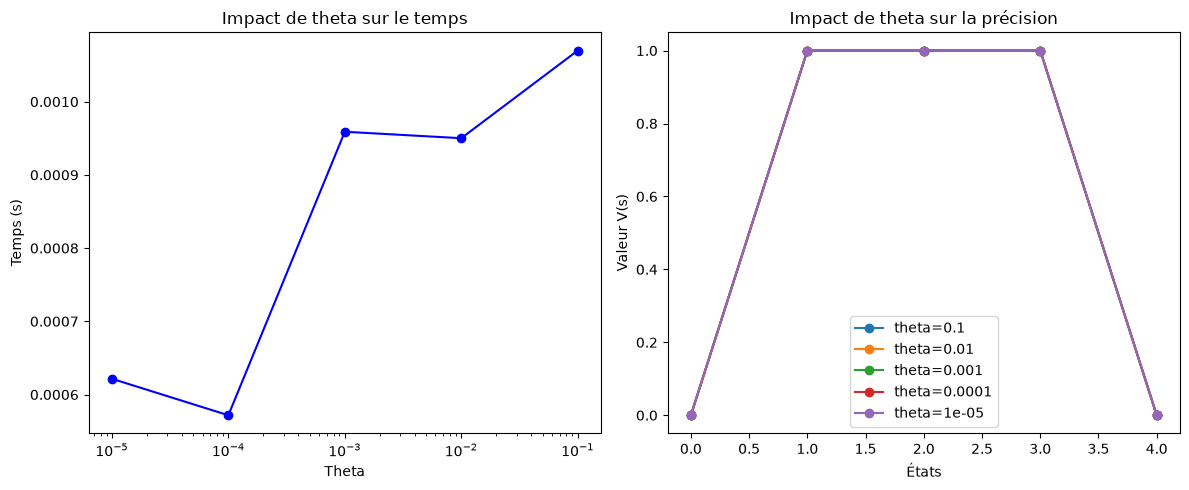

In [11]:
thetas = [0.1, 0.01, 0.001, 0.0001, 0.00001]
times = []
V_results = []

for theta in thetas:
    t = time.time()
    _, V = value_iteration(S, A, R, p, T, theta=theta)
    times.append(time.time() - t)
    V_results.append(V.copy())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(thetas, times, marker='o', color='blue')
ax1.set_xlabel('Theta')
ax1.set_ylabel('Temps (s)')
ax1.set_title('Impact de theta sur le temps')
ax1.set_xscale('log')

for i, theta in enumerate(thetas):
    ax2.plot(S, V_results[i], marker='o', label=f'theta={theta}')
ax2.set_xlabel('États')
ax2.set_ylabel('Valeur V(s)')
ax2.set_title('Impact de theta sur la précision')
ax2.legend()

plt.tight_layout()
plt.show()

theta=0.10000 | temps=0.0007s | précision=0.000000
theta=0.01000 | temps=0.0016s | précision=0.000000
theta=0.00100 | temps=0.0006s | précision=0.000000
theta=0.00010 | temps=0.0006s | précision=0.000000
theta=0.00001 | temps=0.0006s | précision=0.000000


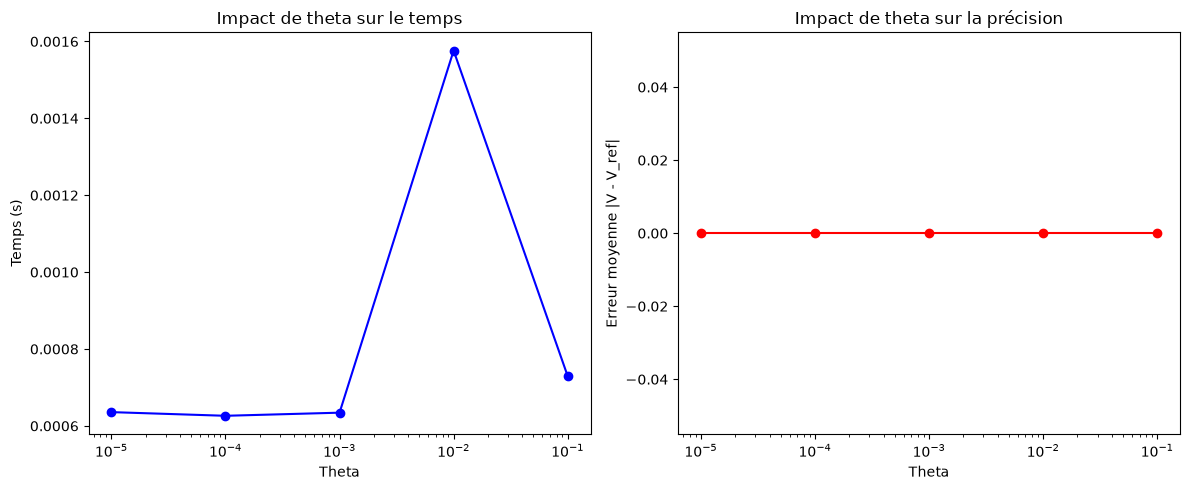

In [12]:
# V de référence
_, V_reference = value_iteration(S, A, R, p, T, theta=0.000001)

thetas = [0.1, 0.01, 0.001, 0.0001, 0.00001]
precisions = []
times = []

for theta in thetas:
    t = time.time()
    _, V = value_iteration(S, A, R, p, T, theta=theta)
    times.append(time.time() - t)
    precision = np.mean(np.abs(V - V_reference))
    precisions.append(precision)
    print(f"theta={theta:.5f} | temps={times[-1]:.4f}s | précision={precision:.6f}")

# Graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(thetas, times, marker='o', color='blue')
ax1.set_xlabel('Theta')
ax1.set_ylabel('Temps (s)')
ax1.set_title('Impact de theta sur le temps')
ax1.set_xscale('log')

ax2.plot(thetas, precisions, marker='o', color='red')
ax2.set_xlabel('Theta')
ax2.set_ylabel('Erreur moyenne |V - V_ref|')
ax2.set_title('Impact de theta sur la précision')
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

Convergence en 5 itérations
V final : [0. 1. 1. 1. 0.]


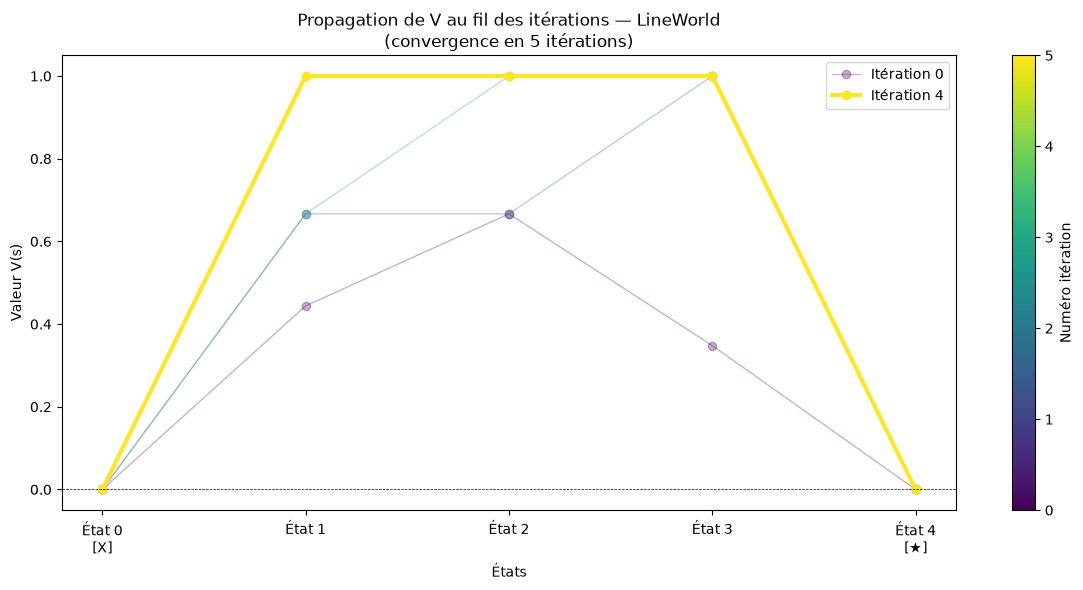

In [13]:
# ================================================
# Expérimentation : Propagation de V au fil des itérations
# On modifie value_iteration pour sauvegarder V à chaque itération
# ================================================

def value_iteration_track(model_S, model_A, model_R, model_p, model_T, gamma=0.99999, theta=0.00001):
    """Value Iteration qui sauvegarde V à chaque itération."""
    V = np.random.random(len(model_S))
    V[model_T] = 0.0
    V_history = [V.copy()]  # on sauvegarde V initial

    while True:
        delta = 0.0
        for s_index in range(len(model_S)):
            v = V[s_index]
            best_value = None
            for a_index in range(len(model_A)):
                total = 0.0
                for s_p_index in range(len(model_S)):
                    for r_index in range(len(model_R)):
                        total += model_p[s_index, a_index, s_p_index, r_index] * (
                            model_R[r_index] + gamma * V[s_p_index]
                        )
                if best_value is None or total > best_value:
                    best_value = total
            V[s_index] = best_value
            delta = np.maximum(delta, np.abs(best_value - v))

        V_history.append(V.copy())  # on sauvegarde V après chaque itération

        if delta < theta:
            break

    return V, V_history

# Lancer et récupérer l'historique
V_final, V_history = value_iteration_track(S, A, R, p, T)

print(f"Convergence en {len(V_history)} itérations")
print(f"V final : {V_final.round(3)}")

# Graphique — évolution de V à chaque itération
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(V_history)))

for i, V in enumerate(V_history):
    label = f'Itération {i}' if i == 0 or i == len(V_history)-1 else None
    alpha = 0.3 if i < len(V_history)-1 else 1.0
    lw = 1 if i < len(V_history)-1 else 3
    ax.plot(S, V, marker='o', color=colors[i], alpha=alpha, linewidth=lw, label=label)

ax.set_xlabel('États')
ax.set_ylabel('Valeur V(s)')
ax.set_title(f'Propagation de V au fil des itérations — LineWorld\n(convergence en {len(V_history)} itérations)')
ax.set_xticks(S)
ax.set_xticklabels(['État 0\n[X]', 'État 1', 'État 2', 'État 3', 'État 4\n[★]'])
ax.legend()
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Colorbar pour montrer la progression
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, len(V_history)))
plt.colorbar(sm, ax=ax, label='Numéro itération')

plt.tight_layout()
plt.show()